# 1부에 이어 계속

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
raw_welfare = pd.read_spss('Koweps_hpwc14_2019_beta2.sav')
welfare = raw_welfare.copy()

welfare.shape       # 14418행, 830열

# 1. 일단 변수명을 바꾼다
welfare = welfare.rename(columns={'h14_g3'  :   'sex',
                                  'h14_g4'  :   'birth',
                                  'h14_g10' :   'marriage_type',
                                  'h14_g11' :   'religion',
                                  'p1402_8aq1'  :   'income',
                                  'h14_eco9'    :   'code_job',
                                  'h14_reg7'    :   'code_region'})
welfare

,h14_id,h14_ind,h14_sn,h14_merkey,h_new,h14_cobf,p14_wsc,p14_wsl,p14_wgc,p14_wgl,...,wc14_64,wc14_65,wc14_5aq4,wc14_5aq5,wc14_5aq6,h14_pers_income1,h14_pers_income2,h14_pers_income3,h14_pers_income4,h14_pers_income5
0,2.0,1.0,1.0,20101.0,0.0,NaN,0.291589,0.291589,1307.764781,1307.764781,...,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
1,3.0,1.0,1.0,30101.0,0.0,NaN,0.419753,0.419753,1882.570960,1882.570960,...,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
2,4.0,1.0,1.0,40101.0,0.0,NaN,0.265263,0.265980,1189.691668,1192.908537,...,NaN,,NaN,NaN,NaN,NaN,1284.0,NaN,0.0,NaN
3,6.0,1.0,1.0,60101.0,0.0,NaN,0.494906,0.495941,2219.630833,2224.273816,...,1.0,.,2.0,4.0,4.0,2304.0,NaN,1800.0,0.0,NaN
4,6.0,1.0,1.0,60101.0,0.0,NaN,1.017935,1.017935,4565.389177,4565.389177,...,1.0,.,1.0,5.0,2.0,NaN,NaN,NaN,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14413,9800.0,7.0,1.0,98000701.0,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
14414,9800.0,7.0,1.0,98000701.0,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
14415,9800.0,7.0,1.0,98000701.0,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,,NaN,NaN,NaN,NaN,208.0,NaN,0.0,NaN
14416,9800.0,7.0,1.0,98000701.0,1.0,NaN,NaN,NaN,NaN,NaN,...,5.0,.,4.0,3.0,3.0,NaN,1200.0,NaN,0.0,NaN


## 종교유무에 따른 이혼율


<Axes: xlabel='marriage', ylabel='n'>

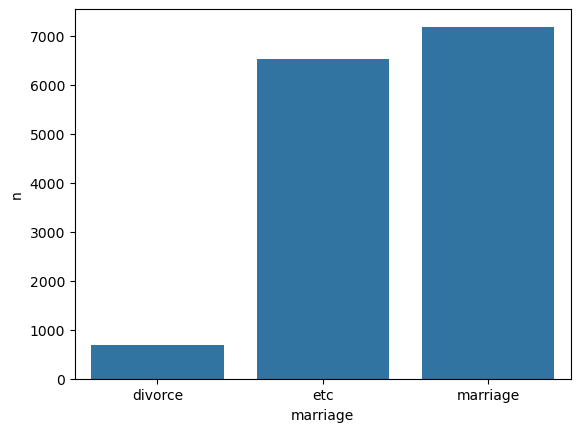

In [3]:
# 종교 변수 체크
# welfare['religion'].dtypes
welfare['religion'] = np.where(welfare['religion'] == 1 , 'yes','no')


# marriage_type변수체크
# welfare['marriage_type'].dtypes
# welfare['marriage_type'].value_counts()
welfare['marriage'] = np.where(welfare['marriage_type'] == 1.0 , 'marriage',
                    np.where(welfare['marriage_type'] == 3.0, 'divorce','etc'))
n_divorce = welfare.groupby('marriage',as_index=False).agg(n = ('marriage','count'))

sns.barplot(data=n_divorce, x='marriage', y='n')
# 1.이혼자 수 2. 기타 수 3. 결혼자 수

<Axes: xlabel='religion', ylabel='pro'>

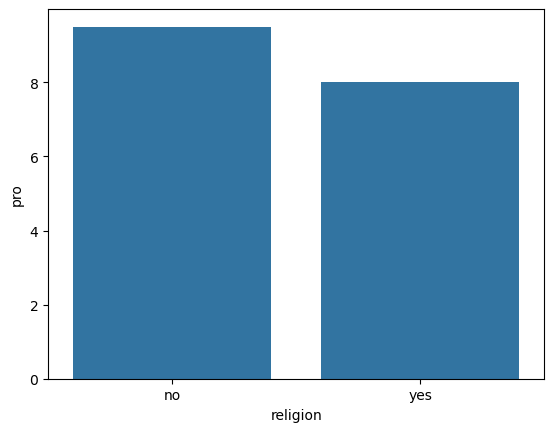

In [4]:
# 문제는 이것을 비율로 표현하는것!
rel_div = welfare.query('marriage != "etc"').groupby('religion',as_index=False)['marriage'].value_counts(normalize=True)
rel_div = rel_div.query('marriage == "divorce"').assign(pro = rel_div['proportion'] * 100).round(1)

sns.barplot(data=rel_div, x='religion' ,y='pro')


<Axes: xlabel='ageg', ylabel='proportion'>

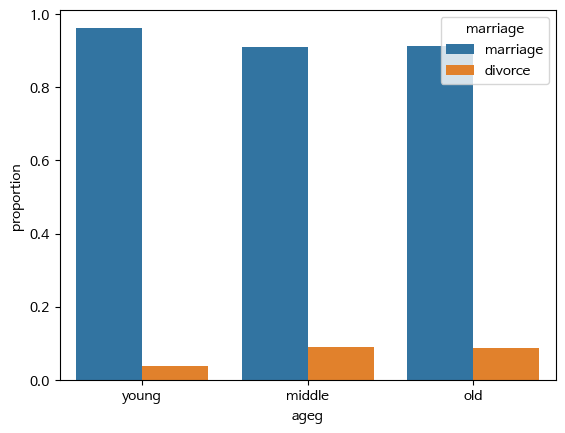

In [33]:
# 연령대,종교유무에 따른 이혼율은?

welfare = welfare.assign(age = 2019 - welfare['birth'] + 1) # 만나이 +1 계산
welfare['ageg'] = np.where(welfare['age'] >= 60, 'old',np.where(welfare['age'] > 30 , 'middle','young'))

age_div = welfare.query('marriage != "etc"').groupby('ageg',as_index=False)['marriage'].value_counts(normalize=True)

sns.barplot(data=age_div, x='ageg',y='proportion',hue='marriage',order=['young','middle','old'])

## 지역별 연령대 비율 분석

In [ ]:
# 지역코드를 실제지역과 매핑할 변수 필요
list_region = pd.DataFrame({'code_region' : [1,2,3,4,5,6,7],
                            'region'    :   ['서울','수도권(경기/인천)','부산/울산/경남','대구/경북','대전/충남','강원/충북','광주/전남/전북/제주']})
welfare = welfare.merge(list_region, how='left',on='code_region') # 병합
welfare # 병합확인

,h14_id,h14_ind,h14_sn,h14_merkey,h_new,h14_cobf,p14_wsc,p14_wsl,p14_wgc,p14_wgl,...,h14_pers_income2,h14_pers_income3,h14_pers_income4,h14_pers_income5,marriage,age,ageg,region_x,region_y,region
0,2.0,1.0,1.0,20101.0,0.0,NaN,0.291589,0.291589,1307.764781,1307.764781,...,NaN,NaN,0.0,NaN,etc,75.0,old,서울,서울,서울
1,3.0,1.0,1.0,30101.0,0.0,NaN,0.419753,0.419753,1882.570960,1882.570960,...,NaN,NaN,0.0,NaN,etc,72.0,old,서울,서울,서울
2,4.0,1.0,1.0,40101.0,0.0,NaN,0.265263,0.265980,1189.691668,1192.908537,...,1284.0,NaN,0.0,NaN,divorce,78.0,old,서울,서울,서울
3,6.0,1.0,1.0,60101.0,0.0,NaN,0.494906,0.495941,2219.630833,2224.273816,...,NaN,1800.0,0.0,NaN,marriage,58.0,middle,서울,서울,서울
4,6.0,1.0,1.0,60101.0,0.0,NaN,1.017935,1.017935,4565.389177,4565.389177,...,NaN,NaN,0.0,NaN,marriage,57.0,middle,서울,서울,서울
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14413,9800.0,7.0,1.0,98000701.0,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,NaN,marriage,53.0,middle,대전/충남,대전/충남,대전/충남
14414,9800.0,7.0,1.0,98000701.0,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,NaN,etc,28.0,young,대전/충남,대전/충남,대전/충남
14415,9800.0,7.0,1.0,98000701.0,1.0,NaN,NaN,NaN,NaN,NaN,...,208.0,NaN,0.0,NaN,etc,25.0,young,대전/충남,대전/충남,대전/충남
14416,9800.0,7.0,1.0,98000701.0,1.0,NaN,NaN,NaN,NaN,NaN,...,1200.0,NaN,0.0,NaN,etc,22.0,young,대전/충남,대전/충남,대전/충남


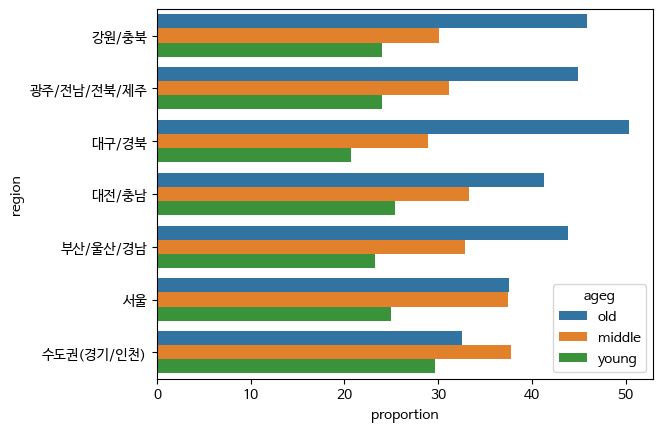

In [ ]:
# 지역별 연령대 비율표
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
plt.rcParams['font.family'] = 'NanumBarunGothic' 

region_ageg = welfare.groupby('region',as_index=False)['ageg'].value_counts(normalize=True) # 지역별로 묶어서 ['ageg']의 백분율을 구한뒤 리턴
region_ageg = region_ageg.assign(proportion = region_ageg['proportion'] *100).round(1) # 소수점을 * 100으로 0.34 --> 34%로 변환

sns.barplot(data=region_ageg, x='proportion',y='region',hue='ageg');

In [ ]:
# 그래프는 그렸으나 문제가 있다, 연령대가 지역별로 따로 떨어져있어 비교가 힘들다
# 누적그래프가 이럴때 좋다
# 피봇으로  변수를 조작한다. index = 행 , columns = 열, values = 값 으로 생각하면된다.
pivot_df = region_ageg[['region','ageg','proportion']].pivot(index='region',columns='ageg',values='proportion')
pivot_df

ageg,middle,old,young
region,,,
강원/충북,30.1,45.9,24.0
광주/전남/전북/제주,31.1,44.9,24.0
대구/경북,28.9,50.4,20.7
대전/충남,33.3,41.3,25.4
부산/울산/경남,32.9,43.8,23.3
서울,37.4,37.6,25.0
수도권(경기/인천),37.8,32.5,29.7


<Axes: ylabel='region'>

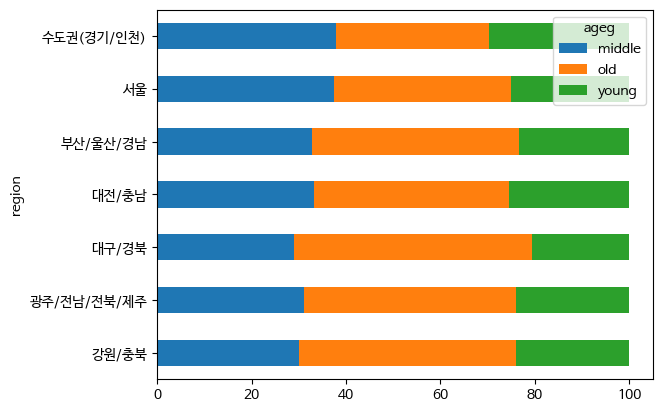

In [ ]:
# 누적 그래프를 그린다
pivot_df.plot.barh(stacked=True)
# 문제가 있다. 비교를 편하게 하려면 정렬이 필요하다

In [ ]:
# old를 비교하고 싶으면 일단 old로 정렬하고 그후 변수 순서를 지정한다
recorder_df = pivot_df.sort_values('old')[['young','middle','old']]
recorder_df

ageg,young,middle,old
region,,,
수도권(경기/인천),29.7,37.8,32.5
서울,25.0,37.4,37.6
대전/충남,25.4,33.3,41.3
부산/울산/경남,23.3,32.9,43.8
광주/전남/전북/제주,24.0,31.1,44.9
강원/충북,24.0,30.1,45.9
대구/경북,20.7,28.9,50.4


<Axes: ylabel='region'>

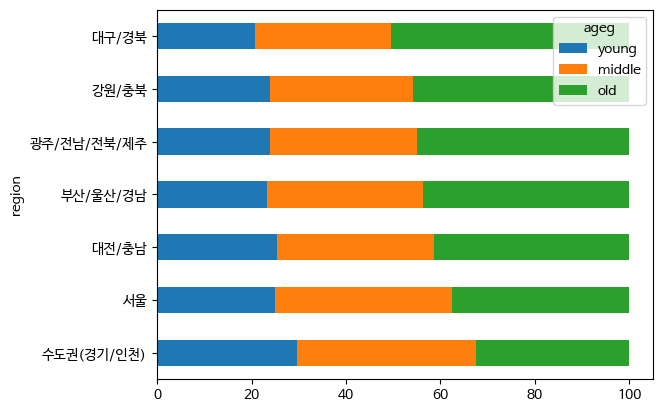

In [ ]:
# 완성되었다. 
recorder_df.plot.barh(stacked=True)

# 대구/경북 -> 강원/충북 -> 광주/전남/전북/제주 ... 순으로 노인인구가 많다는 결과가 나온다